# DigitSense: Handwritten Character Recognition
# CNN-based MNIST Digit Classifier

## IMPORTS

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## LOAD & EXPLORE DATASET

In [3]:
def load_and_explore():
    (X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

    print(f"\nDataset Loaded:")
    print(f"  Training samples : {X_train.shape[0]}")
    print(f"  Test samples     : {X_test.shape[0]}")
    print(f"  Image shape      : {X_train.shape[1:]} (Height x Width)")
    print(f"  Labels           : {np.unique(y_train)} (digits 0-9)")

    plt.figure(figsize=(12, 4))
    plt.suptitle("Sample MNIST Images", fontsize=14, fontweight='bold')
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(X_train[i], cmap='gray')
        plt.title(f"Label: {y_train[i]}")
        plt.axis('off')
    plt.tight_layout()
    plt.savefig("sample_images.png", dpi=100)
    plt.show()

    return (X_train, y_train), (X_test, y_test)

## PREPROCESSING

In [4]:
def preprocess(X_train, y_train, X_test, y_test):
    # Normalize pixel values [0, 255] → [0, 1]
    X_train = X_train.astype("float32") / 255.0
    X_test  = X_test.astype("float32")  / 255.0

    # Reshape for CNN: (samples, height, width, channels)
    X_train = X_train.reshape(-1, 28, 28, 1)
    X_test  = X_test.reshape(-1, 28, 28, 1)

    # One-hot encode labels: e.g., 3 → [0,0,0,1,0,0,0,0,0,0]
    y_train_enc = to_categorical(y_train, num_classes=10)
    y_test_enc  = to_categorical(y_test,  num_classes=10)

    print(f"\nPreprocessing Done:")
    print(f"  X_train shape : {X_train.shape}")
    print(f"  X_test shape  : {X_test.shape}")

    return X_train, y_train_enc, X_test, y_test_enc

## BUILD CNN MODEL

In [5]:
def build_model():
    """
    CNN Architecture:
    Input (28x28x1)
    → Conv2D(32, 3x3) + ReLU → MaxPool(2x2)
    → Conv2D(64, 3x3) + ReLU → MaxPool(2x2)
    → Flatten → Dense(128) + Dropout(0.3)
    → Output Dense(10) + Softmax
    """
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), name='conv1'),
        layers.MaxPooling2D((2, 2), name='pool1'),

        layers.Conv2D(64, (3, 3), activation='relu', name='conv2'),
        layers.MaxPooling2D((2, 2), name='pool2'),

        layers.Flatten(name='flatten'),
        layers.Dense(128, activation='relu', name='dense1'),
        layers.Dropout(0.3, name='dropout'),
        layers.Dense(10, activation='softmax', name='output')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.summary()
    return model

## TRAIN MODEL

In [6]:
def train_model(model, X_train, y_train, X_test, y_test_enc):
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True
    )
    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, verbose=1
    )

    print("\nTraining started...")
    history = model.fit(
        X_train, y_train,
        epochs=15,
        batch_size=64,
        validation_split=0.1,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    test_loss, test_acc = model.evaluate(X_test, y_test_enc, verbose=0)
    print(f"\nTest Accuracy : {test_acc * 100:.2f}%")
    print(f"   Test Loss     : {test_loss:.4f}")

    return history

## VISUALIZE TRAINING CURVES

In [7]:
def plot_training(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Training Performance", fontsize=14, fontweight='bold')

    axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='blue')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train Loss', color='blue')
    axes[1].plot(history.history['val_loss'], label='Val Loss',   color='orange')
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=100)
    plt.show()

## EVALUATE & CONFUSION MATRIX

In [8]:
def evaluate_model(model, X_test, y_test_raw):
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    print("\nClassification Report:")
    print(classification_report(y_test_raw, y_pred,
                                 target_names=[str(i) for i in range(10)]))

    cm = confusion_matrix(y_test_raw, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(10), yticklabels=range(10))
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=100)
    plt.show()

## VISUALIZE PREDICTIONS

In [9]:
def visualize_predictions(model, X_test, y_test_raw):
    y_pred = np.argmax(model.predict(X_test[:25], verbose=0), axis=1)

    plt.figure(figsize=(14, 6))
    plt.suptitle("Predictions (Green=Correct, Red=Wrong)", fontsize=13, fontweight='bold')
    for i in range(25):
        plt.subplot(5, 5, i + 1)
        plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
        color = 'green' if y_pred[i] == y_test_raw[i] else 'red'
        plt.title(f"P:{y_pred[i]} T:{y_test_raw[i]}", color=color, fontsize=8)
        plt.axis('off')
    plt.tight_layout()
    plt.savefig("predictions.png", dpi=100)
    plt.show()

## SAVE MODEL

In [10]:
def save_model(model):
    model.save("digitsense_model.keras")
    print("\nModel saved as digitsense_model.keras")
    print("   Reload: model = keras.models.load_model('digitsense_model.keras')")

## MAIN PIPELINE

   DigitSense: Handwritten Digit Recognition (CNN)
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Dataset Loaded:
  Training samples : 60000
  Test samples     : 10000
  Image shape      : (28, 28) (Height x Width)
  Labels           : [0 1 2 3 4 5 6 7 8 9] (digits 0-9)


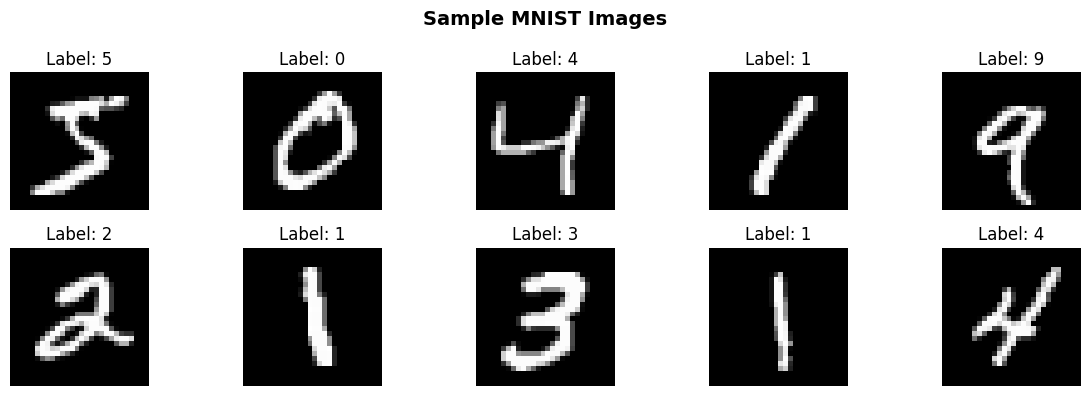


Preprocessing Done:
  X_train shape : (60000, 28, 28, 1)
  X_test shape  : (10000, 28, 28, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)


Training started...
Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - accuracy: 0.9338 - loss: 0.2146 - val_accuracy: 0.9838 - val_loss: 0.0566 - learning_rate: 0.0010
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.9806 - loss: 0.0651 - val_accuracy: 0.9887 - val_loss: 0.0392 - learning_rate: 0.0010
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - accuracy: 0.9849 - loss: 0.0484 - val_accuracy: 0.9890 - val_loss: 0.0366 - learning_rate: 0.0010
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.9881 - loss: 0.0371 - val_accuracy: 0.9903 - val_loss: 0.0320 - learning_rate: 0.0010
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.9907 - loss: 0.0298 - val_accuracy: 0.9913 - val_loss: 0.0302 - learning_rate: 0.0010
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9920 - loss: 0.0259 - val_accuracy: 0.9927 - val_loss: 0.0322 - learning_rate: 0.0010
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step -

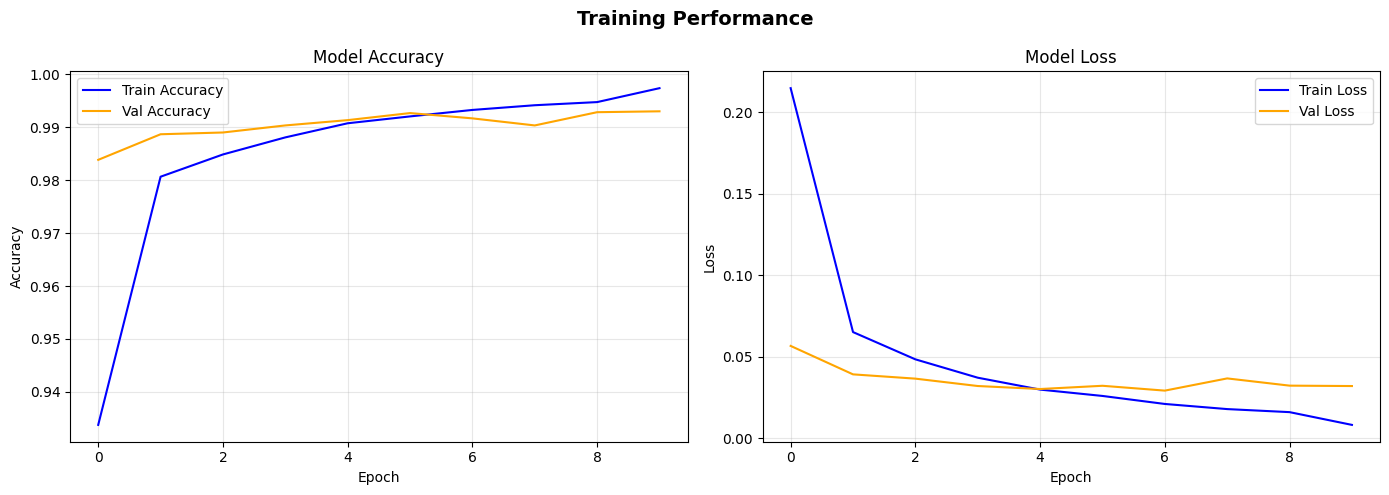


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



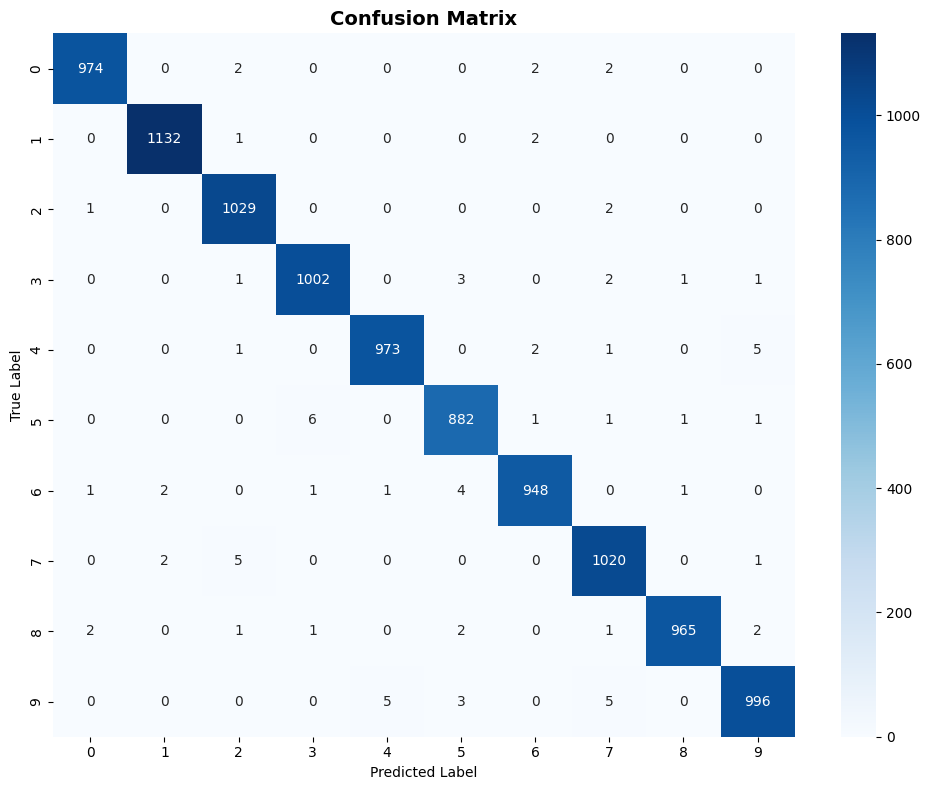

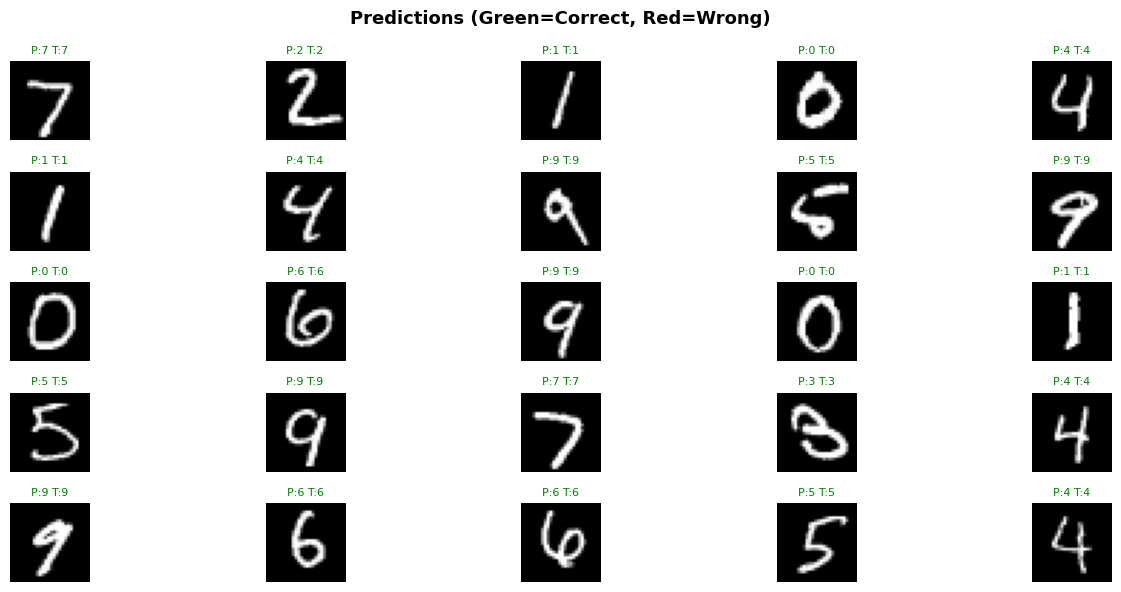


Model saved as digitsense_model.keras
   Reload: model = keras.models.load_model('digitsense_model.keras')

DigitSense complete!


In [11]:
if __name__ == "__main__":
    print("=" * 55)
    print("   DigitSense: Handwritten Digit Recognition (CNN)")
    print("=" * 55)

    (X_train, y_train), (X_test, y_test) = load_and_explore()
    X_train_p, y_train_p, X_test_p, y_test_p = preprocess(X_train, y_train, X_test, y_test)
    model = build_model()
    history = train_model(model, X_train_p, y_train_p, X_test_p, y_test_p)
    plot_training(history)
    evaluate_model(model, X_test_p, y_test)
    visualize_predictions(model, X_test_p, y_test)
    save_model(model)